# Dynamic Treatment Histories: Stabilized MSM vs. Dynamic Balance

This notebook builds a small two-period panel with time-varying confounding and compares two estimators for the treatment-history contrast

$$
\mathbb{E}[Y_2(1,1) - Y_2(0,0)].
$$

The setup follows the two-period picture in Davide Viviano's slide deck on dynamic covariate balancing: baseline covariates and treatment at $t=1$, intermediate outcomes and covariates at $t=2$, and a final outcome after the second treatment decision.

References:

- Davide Viviano and Jelena Bradic, [Dynamic Covariate Balancing: Estimating Treatment Effects over Time with Potential Local Projections](https://dviviano.github.io/projects/pres_DT_june_2023.pdf)
- The `DynamicBalance` implementation in this repository

## What the notebook does

1. Simulate a two-period observational study where treatment assignment depends on observed history.
2. Estimate a saturated two-period Robins-style marginal structural model using stabilized inverse-probability weights.
3. Estimate the same history contrast with `DynamicBalance`.
4. Compare the two estimators on one weak-overlap sample and then across repeated simulations under moderate and weak overlap.

The design is deliberately simple. The point is not to recreate the full paper, but to make the mechanics of the two approaches concrete in one place.

In [1]:
import warnings
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression

from synthlearners import DynamicBalance

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="talk")
pd.options.display.float_format = "{:.3f}".format

TARGET_HISTORY = (1, 1)
REFERENCE_HISTORY = (0, 0)
TRUE_CONTRAST = 3.85

## Simulation design

The observed data are generated by

$$
X_1 \sim \mathcal{N}(0, 1), \qquad
D_1 \sim \text{Bernoulli}(\operatorname{logit}^{-1}(a_0 + a_1 X_1)),
$$

$$
Y_1 = 0.6 X_1 + 1.0 D_1 + \varepsilon_1,
$$

$$
X_2 = 0.5 X_1 + 0.7 Y_1 + 0.8 D_1 + \varepsilon_x,
$$

$$
D_2 \sim \text{Bernoulli}(\operatorname{logit}^{-1}(b_0 + b_1 X_1 + b_2 Y_1 + b_3 X_2 + b_4 D_1)),
$$

$$
Y_2 = 0.3 X_1 + 0.4 Y_1 + 0.5 X_2 + 0.8 D_1 + 1.4 D_2 + 0.5 D_1 D_2 + \varepsilon_2.
$$

The outcome model is fixed. Only the treatment-assignment coefficients change across the `moderate` and `weak` overlap regimes.

Because the structural equations are linear, we can derive the truth analytically. Substituting the equations for $Y_1$ and $X_2$ into $Y_2$ gives

$$
Y_2(d_1, d_2) = X_1 + 1.95 d_1 + 1.4 d_2 + 0.5 d_1 d_2 + \xi,
$$

where $\xi$ collects the shock terms. Therefore

$$
\mathbb{E}[Y_2(1,1) - Y_2(0,0)] = 1.95 + 1.4 + 0.5 = 3.85.
$$

This matters because it lets us judge both estimators against a known target.

In [2]:
OVERLAP_CONFIG = {
    "moderate": {
        "d1_intercept": -0.1,
        "d1_slope": 0.9,
        "d2": (-0.3, 0.4, 0.9, 0.9, 0.4),
    },
    "weak": {
        "d1_intercept": 0.2,
        "d1_slope": 1.8,
        "d2": (0.7, 0.8, 1.8, 1.6, 0.8),
    },
}


@dataclass
class MSMResult:
    contrast: float
    regime_means: dict
    weights: np.ndarray
    ess: float
    max_weight: float
    quantiles: dict


@dataclass
class DynamicBalanceSummary:
    contrast: float
    result: object
    period_diagnostics: pd.DataFrame
    final_summary: pd.DataFrame


def sigmoid(z: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-z))


def observed_probability(prob: np.ndarray, treatment: np.ndarray) -> np.ndarray:
    treatment = np.asarray(treatment)
    return np.where(treatment == 1, prob, 1.0 - prob)


def simulate_dynamic_panel(
    n_units: int = 800,
    seed: int = 0,
    overlap: str = "weak",
) -> tuple[pd.DataFrame, pd.DataFrame]:
    rng = np.random.default_rng(seed)
    config = OVERLAP_CONFIG[overlap]

    x1 = rng.normal(size=n_units)
    eps1 = rng.normal(scale=0.6, size=n_units)
    eps_x = rng.normal(scale=0.6, size=n_units)
    eps2 = rng.normal(scale=0.6, size=n_units)

    p1 = sigmoid(config["d1_intercept"] + config["d1_slope"] * x1)
    d1 = rng.binomial(1, p1)

    y1 = 0.6 * x1 + 1.0 * d1 + eps1
    x2 = 0.5 * x1 + 0.7 * y1 + 0.8 * d1 + eps_x

    b0, b1, b2, b3, b4 = config["d2"]
    p2 = sigmoid(b0 + b1 * x1 + b2 * y1 + b3 * x2 + b4 * d1)
    d2 = rng.binomial(1, p2)

    y2 = 0.3 * x1 + 0.4 * y1 + 0.5 * x2 + 0.8 * d1 + 1.4 * d2 + 0.5 * d1 * d2 + eps2

    wide = pd.DataFrame(
        {
            "unit": np.arange(n_units),
            "x1": x1,
            "d1": d1,
            "y1": y1,
            "x2": x2,
            "d2": d2,
            "y2": y2,
            "p1": p1,
            "p2": p2,
        }
    )

    long = pd.concat(
        [
            pd.DataFrame(
                {
                    "unit": np.arange(n_units),
                    "time": 1,
                    "treatment": d1,
                    "outcome": y1,
                    "x": x1,
                    "lag_outcome": np.zeros(n_units),
                }
            ),
            pd.DataFrame(
                {
                    "unit": np.arange(n_units),
                    "time": 2,
                    "treatment": d2,
                    "outcome": y2,
                    "x": x2,
                    "lag_outcome": y1,
                }
            ),
        ],
        ignore_index=True,
    )
    return wide, long


def fit_logit(features: np.ndarray, treatment: np.ndarray) -> LogisticRegression:
    model = LogisticRegression(C=1e6, solver="lbfgs", max_iter=2000)
    model.fit(features, treatment)
    return model


def fit_stabilized_ipw_msm(wide: pd.DataFrame) -> MSMResult:
    x1 = wide[["x1"]].to_numpy()
    history_t2 = wide[["x1", "d1", "y1", "x2"]].to_numpy()
    d1 = wide["d1"].to_numpy()
    d2 = wide["d2"].to_numpy()
    y2 = wide["y2"].to_numpy()

    p1_den = fit_logit(x1, d1).predict_proba(x1)[:, 1]
    p2_den = fit_logit(history_t2, d2).predict_proba(history_t2)[:, 1]
    p1_den = np.clip(p1_den, 1e-6, 1.0 - 1e-6)
    p2_den = np.clip(p2_den, 1e-6, 1.0 - 1e-6)

    p1_num = np.repeat(d1.mean(), len(wide))
    p2_num = fit_logit(wide[["d1"]].to_numpy(), d2).predict_proba(wide[["d1"]].to_numpy())[:, 1]
    p2_num = np.clip(p2_num, 1e-6, 1.0 - 1e-6)

    weights = observed_probability(p1_num, d1) * observed_probability(p2_num, d2)
    weights /= observed_probability(p1_den, d1) * observed_probability(p2_den, d2)

    design = np.column_stack(
        [
            np.ones(len(wide)),
            d1,
            d2,
            d1 * d2,
        ]
    )
    root_w = np.sqrt(weights)
    beta, *_ = np.linalg.lstsq(design * root_w[:, None], y2 * root_w, rcond=None)

    def predict(history: tuple[int, int]) -> float:
        row = np.array([1.0, history[0], history[1], history[0] * history[1]])
        return float(row @ beta)

    regime_means = {
        "(0,0)": predict((0, 0)),
        "(0,1)": predict((0, 1)),
        "(1,0)": predict((1, 0)),
        "(1,1)": predict((1, 1)),
    }
    ess = float((weights.sum() ** 2) / np.sum(weights ** 2))
    quantiles = {
        "p50": float(np.quantile(weights, 0.50)),
        "p95": float(np.quantile(weights, 0.95)),
        "p99": float(np.quantile(weights, 0.99)),
    }
    return MSMResult(
        contrast=regime_means["(1,1)"] - regime_means["(0,0)"],
        regime_means=regime_means,
        weights=weights,
        ess=ess,
        max_weight=float(weights.max()),
        quantiles=quantiles,
    )


def _history_period_diagnostics(label: str, estimate) -> pd.DataFrame:
    rows = []
    for period_idx, (weights, ess, eligible, gap) in enumerate(
        zip(
            estimate.weights_by_period,
            estimate.effective_sample_sizes,
            estimate.eligible_counts,
            estimate.balance_gaps,
            strict=True,
        ),
        start=1,
    ):
        rows.append(
            {
                "history": label,
                "period": period_idx,
                "eligible_units": int(eligible),
                "effective_sample_size": float(ess),
                "max_weight": float(weights.max()),
                "max_abs_balance_gap": float(np.max(np.abs(gap))) if len(gap) else 0.0,
            }
        )
    return pd.DataFrame(rows)


def fit_dynamic_balance(long: pd.DataFrame) -> DynamicBalanceSummary:
    result = DynamicBalance(balance_grid_size=10, l1_ratio=0.0).fit(
        df=long,
        unit_id="unit",
        time_id="time",
        treatment="treatment",
        outcome="outcome",
        covariates=["x", "lag_outcome"],
        target_history=TARGET_HISTORY,
        reference_history=REFERENCE_HISTORY,
    )

    diagnostics = pd.concat(
        [
            _history_period_diagnostics("target", result.target),
            _history_period_diagnostics("reference", result.reference),
        ],
        ignore_index=True,
    )
    final_summary = pd.DataFrame(
        [
            {
                "history": "target",
                "history_value": result.target.history,
                "mean_outcome": result.target.mean_outcome,
                "final_ess": result.target.effective_sample_sizes[-1],
                "final_max_weight": float(result.target.weights_by_period[-1].max()),
            },
            {
                "history": "reference",
                "history_value": result.reference.history,
                "mean_outcome": result.reference.mean_outcome,
                "final_ess": result.reference.effective_sample_sizes[-1],
                "final_max_weight": float(result.reference.weights_by_period[-1].max()),
            },
        ]
    )
    return DynamicBalanceSummary(
        contrast=result.contrast,
        result=result,
        period_diagnostics=diagnostics,
        final_summary=final_summary,
    )


def compare_methods(n_replications: int = 12, n_units: int = 600) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    for overlap in ["moderate", "weak"]:
        for seed in range(n_replications):
            wide, long = simulate_dynamic_panel(n_units=n_units, seed=seed, overlap=overlap)
            msm = fit_stabilized_ipw_msm(wide)
            dyn = fit_dynamic_balance(long)

            rows.append(
                {
                    "overlap": overlap,
                    "seed": seed,
                    "method": "Stabilized MSM",
                    "estimate": msm.contrast,
                    "error": msm.contrast - TRUE_CONTRAST,
                    "effective_sample_size": msm.ess,
                    "max_weight": msm.max_weight,
                }
            )
            rows.append(
                {
                    "overlap": overlap,
                    "seed": seed,
                    "method": "DynamicBalance",
                    "estimate": dyn.contrast,
                    "error": dyn.contrast - TRUE_CONTRAST,
                    "effective_sample_size": float(
                        dyn.final_summary["final_ess"].min()
                    ),
                    "max_weight": float(
                        dyn.final_summary["final_max_weight"].max()
                    ),
                }
            )

    results = pd.DataFrame(rows)
    summary = (
        results.groupby(["overlap", "method"], as_index=False)
        .agg(
            mean_estimate=("estimate", "mean"),
            mean_bias=("error", "mean"),
            mean_abs_error=("error", lambda x: float(np.mean(np.abs(x)))),
            rmse=("error", lambda x: float(np.sqrt(np.mean(np.square(x))))),
            avg_ess=("effective_sample_size", "mean"),
            avg_max_weight=("max_weight", "mean"),
        )
    )
    return results, summary

## One weak-overlap sample

The slide deck emphasizes that dynamic selection and weak overlap are where inverse-probability weighting becomes fragile. To make that visible, the worked example below uses the `weak` overlap regime with `seed = 8`.

In [3]:
example_wide, example_long = simulate_dynamic_panel(
    n_units=800,
    seed=8,
    overlap="weak",
)

history_counts = (
    example_wide.groupby(["d1", "d2"])
    .size()
    .rename("count")
    .reset_index()
)
history_counts["history"] = list(zip(history_counts["d1"], history_counts["d2"]))
history_counts[["history", "count"]]

,history,count
0,"(0, 0)",238
1,"(0, 1)",123
2,"(1, 0)",6
3,"(1, 1)",433


## Classical Robins-style estimator: stabilized IPW + a saturated MSM

In this two-period example, a standard approach is:

1. Estimate the treatment models
   $$P(D_1 = 1 \mid X_1), \qquad P(D_2 = 1 \mid X_1, D_1, Y_1, X_2).$$
2. Build stabilized inverse-probability weights
   $$W_i = \prod_{t=1}^2 \frac{P(D_{i,t} \mid \bar{D}_{i,t-1})}{P(D_{i,t} \mid \bar{L}_{i,t}, \bar{D}_{i,t-1})}.$$
3. Fit a weighted, saturated marginal structural model
   $$E[Y_2(d_1, d_2)] = \beta_0 + \beta_1 d_1 + \beta_2 d_2 + \beta_3 d_1 d_2.$$

In this notebook the treatment models are simple logistic regressions. That keeps the example close to the classical MSM workflow while making the role of the estimated weights explicit.

In [4]:
msm_example = fit_stabilized_ipw_msm(example_wide)

msm_summary = pd.DataFrame(
    [
        {"quantity": "true contrast", "value": TRUE_CONTRAST},
        {"quantity": "MSM estimate", "value": msm_example.contrast},
        {"quantity": "MSM error", "value": msm_example.contrast - TRUE_CONTRAST},
        {"quantity": "MSM ESS", "value": msm_example.ess},
        {"quantity": "MSM max weight", "value": msm_example.max_weight},
        {"quantity": "MSM weight p95", "value": msm_example.quantiles["p95"]},
        {"quantity": "MSM weight p99", "value": msm_example.quantiles["p99"]},
    ]
)
msm_summary

,quantity,value
0,true contrast,3.850
1,MSM estimate,2.537
2,MSM error,-1.313
3,MSM ESS,2.855
4,MSM max weight,1065.504
5,MSM weight p95,1.996
6,MSM weight p99,9.458


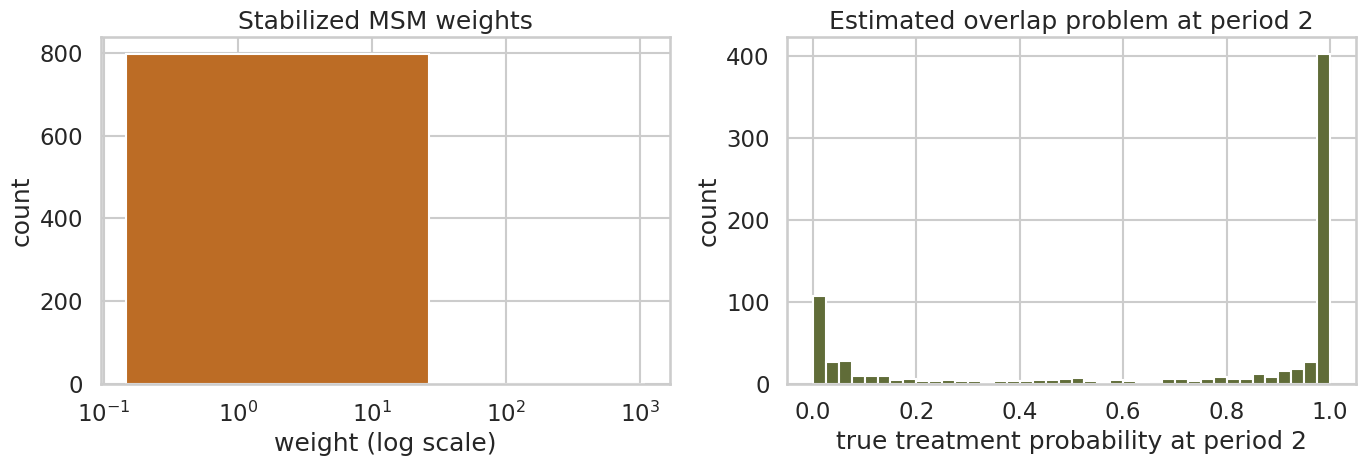

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(msm_example.weights, bins=40, color="#bc6c25", edgecolor="white")
axes[0].set_xscale("log")
axes[0].set_title("Stabilized MSM weights")
axes[0].set_xlabel("weight (log scale)")
axes[0].set_ylabel("count")

axes[1].hist(example_wide["p2"], bins=40, color="#606c38", edgecolor="white")
axes[1].set_title("Estimated overlap problem at period 2")
axes[1].set_xlabel("true treatment probability at period 2")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

## DynamicBalance in this repository

`DynamicBalance` avoids explicit propensity-score estimation. Instead it:

1. Builds recursive outcome projections period by period.
2. Solves sequential balancing problems over units whose observed history matches each treatment prefix.
3. Combines the final weighted outcome with a telescoping correction from the recursive projections.

In the Viviano-Bradic slides, this is motivated as a way to control the sequential bias terms while avoiding direct specification of the dynamic propensity score. The current Python implementation is intentionally scoped to balanced panels, exact histories, and a single final outcome period.

In [6]:
dyn_example = fit_dynamic_balance(example_long)

comparison = pd.DataFrame(
    [
        {"estimator": "truth", "estimate": TRUE_CONTRAST, "error": 0.0},
        {"estimator": "stabilized MSM", "estimate": msm_example.contrast, "error": msm_example.contrast - TRUE_CONTRAST},
        {"estimator": "DynamicBalance", "estimate": dyn_example.contrast, "error": dyn_example.contrast - TRUE_CONTRAST},
    ]
)
comparison

,estimator,estimate,error
0,truth,3.850,0.000
1,stabilized MSM,2.537,-1.313
2,DynamicBalance,3.956,0.106


In [7]:
dyn_example.final_summary

,history,history_value,mean_outcome,final_ess,final_max_weight
0,target,"(1, 1)",3.892,337.108,0.006
1,reference,"(0, 0)",-0.064,57.673,0.046


In [8]:
dyn_example.period_diagnostics

,history,period,eligible_units,effective_sample_size,max_weight,max_abs_balance_gap
0,target,1,439,291.572,0.007,0.000
1,target,2,433,337.108,0.006,0.000
2,reference,1,361,206.989,0.012,0.000
3,reference,2,238,57.673,0.046,0.000


In this particular weak-overlap sample, the MSM estimate is pulled around by a small number of very large stabilized weights, while `DynamicBalance` stays much closer to the true contrast. That is exactly the comparison the slides are trying to make intuitive: both estimators target the same treatment-history mean, but one relies on estimated propensity weights and the other solves a constrained balancing problem directly.

## Repeated simulations

A single dataset can always be lucky or unlucky, so the next block repeats the experiment under two overlap regimes.

- `moderate`: treatment assignment still depends strongly on observed history, but overlap is workable.
- `weak`: treatment propensities get much closer to zero and one, so the IPW part of the MSM becomes unstable.

The outcome model and the true contrast stay fixed at `3.85` throughout.

In [9]:
simulation_results, simulation_summary = compare_methods(
    n_replications=12,
    n_units=600,
)

simulation_summary

,overlap,method,mean_estimate,mean_bias,mean_abs_error,rmse,avg_ess,avg_max_weight
0,moderate,DynamicBalance,3.963,0.113,0.116,0.140,113.629,0.019
1,moderate,Stabilized MSM,3.844,-0.006,0.247,0.320,209.857,30.013
2,weak,DynamicBalance,4.035,0.185,0.185,0.226,40.027,0.064
3,weak,Stabilized MSM,4.262,0.412,0.521,0.557,148.815,54.146


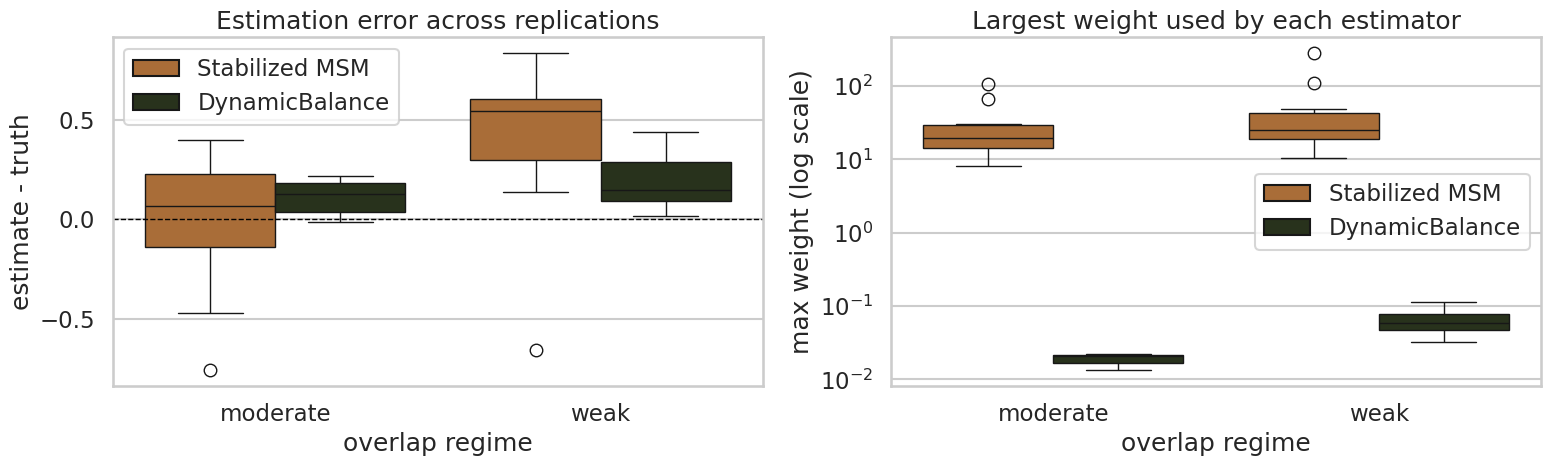

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(
    data=simulation_results,
    x="overlap",
    y="error",
    hue="method",
    ax=axes[0],
    palette=["#bc6c25", "#283618"],
)
axes[0].axhline(0.0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Estimation error across replications")
axes[0].set_ylabel("estimate - truth")
axes[0].set_xlabel("overlap regime")

sns.boxplot(
    data=simulation_results,
    x="overlap",
    y="max_weight",
    hue="method",
    ax=axes[1],
    palette=["#bc6c25", "#283618"],
)
axes[1].set_yscale("log")
axes[1].set_title("Largest weight used by each estimator")
axes[1].set_ylabel("max weight (log scale)")
axes[1].set_xlabel("overlap regime")

for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], frameon=True)

plt.tight_layout()
plt.show()

## Takeaways

- In this synthetic design, the classical stabilized MSM is well-motivated because treatment depends only on observed history.
- Under moderate overlap, the MSM works reasonably well, although its error is still noticeably more variable than `DynamicBalance` in finite samples.
- Under weak overlap, the stabilized IPW step becomes fragile and very large weights show up quickly.
- `DynamicBalance` is not magic and it is still a finite-sample estimator, but in this design it is materially more stable because it replaces explicit propensity estimation with sequential balance constraints.

The notebook is intentionally small. If you want to push further, the next natural extensions are longer treatment histories, more flexible nuisance models for the MSM, and a direct comparison to the original DynBalancing R package.